In [1]:
import pandas as pd
import numpy as np
import numpy.linalg as LA
import random
import matplotlib.pyplot as plt

Problem 1

In [2]:
def generate_noisy_data(functions, true_function, x_range, n_samples, epsilon):
  """
  Generate a DataFrame of noisy samples by evaluating each function and the true function at random x values.

  functions: a series of lambdas, each taking a single numerical value
  true_function: a lambda that computes a single numerical value
  x_range: a list of length 2 defining the range of x values to sample from
  n_samples: a positive integer for how many samples to generate
  epsilon: a noise value added to or subtracted from the true value
  """
  rows = []
  for _ in range(n_samples):
    x_val = random.uniform(x_range[0], x_range[1])

    function_results = []
    for function in functions:
      val = function(x_val)
      function_results.append(val)

    true_val = true_function(x_val)
    esp_val = random.choice([-epsilon, epsilon])
    function_results.append(true_val + esp_val)

    rows.append(function_results)

  columns = [f"f{i}" for i in range(len(functions))] + ["y"]
  return pd.DataFrame(rows, columns=columns)

In [3]:
df = generate_noisy_data(
  functions=[lambda x: x, lambda x: x**2, lambda x: x**3],
  true_function=lambda x: np.log(x),
  x_range=[0,1],
  n_samples=100,
  epsilon=0.5
)

df.head()

,f0,f1,f2,y
0,0.393196,0.154603,0.060789,-0.433448
1,0.811639,0.658757,0.534673,0.291300
2,0.238550,0.056906,0.013575,-0.933177
3,0.177559,0.031527,0.005598,-1.228450
4,0.741870,0.550370,0.408303,-0.798582


Problem 2

In [4]:
# Fits a linear regression model using the closed-form solution to the training data provided
def fit(train_data):
  y = train_data["y"]
  X = train_data.drop(columns=["y"])
  X.insert(0, "intercept", 1)

  weights = (LA.inv(X.T.dot(X))).dot(X.T).dot(y)
  return weights

df_train = df.sample(frac=0.8, random_state=42)
weights = fit(df_train)
print(weights)

[ -3.75159127  13.67000222 -19.87658494  10.14222679]


In [5]:
# Computes the predictions using weights and the testing dataset features
def predict(weights, test_data_x):
  y_preds = weights.dot(test_data_x)
  return y_preds

In [6]:
# Computes RMSE between the predicted y-values and the real ones
def evaluate(y_preds, test_data_y):
  squared_loss_val = ((y_preds - test_data_y) ** 2).sum()
  return np.sqrt(squared_loss_val / len(test_data_y))

Problem 3

In [7]:
def plot_results(train_data, true_function, weights, functions, title=""):                                                                                                           
  x_vals = np.linspace(0, 1, 200)                       

  # Scatterplot of training data
  plt.scatter(train_data["f0"], train_data["y"], alpha=0.4, label="Training data")

  # True function curve
  plt.plot(x_vals, [true_function(x) for x in x_vals], color="green", label="True function")
                                                                                                                                                                        
  # Linear model line                                                                                                                                            
  X_plot = np.column_stack([np.ones(200)] + [f(x_vals) for f in functions])
  # Calculate the y model                                                                                                                   
  y_model = X_plot.dot(weights)                                                                                                                                         
  plt.plot(x_vals, y_model, color="red", label="Linear model")                                                                                                          
                                                                                                                                                                        
  plt.xlabel("x")                                                                                                                                                       
  plt.ylabel("y")                                                                                                                                                       
  plt.title(title)                                                                                                                                        
  plt.legend()  

True Function = Cubic, Epsilon = 0.01, RMSE = 0.0101


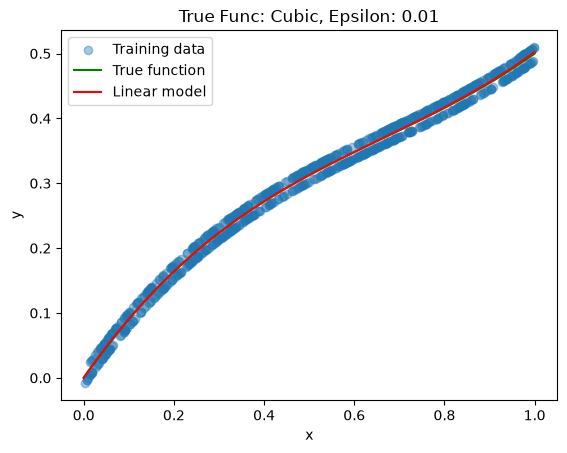

In [8]:
# All combinations of true functinos and epsilons
#true_function = lambda x: 2*x + 1
true_function = lambda x: 0.5*x**3 - x**2 + x                                                                                                                                                                                                                                                                                    
                                                                                                                                                                       
epsilon = 0.01
#epsilon = 0.1

functions=[lambda x: x, lambda x: x**2, lambda x: x**3]

# Get data based on requirements                                                                                                                                               
df = generate_noisy_data(                                                                                                                                         
    functions=functions,                                                                       
    true_function=true_function,                                             
    x_range=[0, 1],                                                                                                                                           
    n_samples=1000,                                                                                                                                      
    epsilon=epsilon                                                                                                                              
)

# Split data into training and testing
df_train = df.sample(frac=0.8, random_state=42)                                                                                                                   
df_test = df.drop(df_train.index)                                                                                                                                 

# Fit model                                                                                                                                                      
weights = fit(df_train)                                                                                                                                           

# Split test data, add corresponding intercept, and get predictions                                                                                                                             
test_X = df_test.drop(columns=["y"])                                                                                                                              
test_X.insert(0, "intercept", 1)                  
y_preds = predict(weights, test_X.T)

# Evaluate predictions                                                                                                                                                                                                                                            
rmse = evaluate(y_preds, df_test["y"])                                                                                                                            
print(f"True Function = Cubic, Epsilon = {epsilon}, RMSE = {rmse:.4f}")                                                                                                                    

# Create appropriate scatterplot                                                                                        
plot_results(df_train, true_function, weights, functions, title=f"True Func: Cubic, Epsilon: {epsilon}")  

Problem 5

In [9]:
# All combinations of true functinos and epsilons
#true_function = lambda x: 2*x + 1
true_function = lambda x: 0.5*x**3 - x**2 + x                                                                                                                                                                                                                                                                                    
                                                                                                                                                                       
epsilon = 0.01
#epsilon = 0.1

functions=[lambda x: x, lambda x: x**2, lambda x: x**3]

# Get data based on requirements                                                                                                                                               
df = generate_noisy_data(                                                                                                                                         
    functions=functions,                                                                       
    true_function=true_function,                                             
    x_range=[0, 1],                                                                                                                                           
    n_samples=1000,                                                                                                                                      
    epsilon=epsilon                                                                                                                              
)

# Split data into training and testing
df_train = df.sample(frac=0.8, random_state=42)                                                                                                           

# Fit model                                                                                                                                                      
weights = fit(df_train)

# Get the one single x point of 10
x_point = np.array([1, 10, 10**2, 10**3])
pred = weights.dot(x_point)

true_val = true_function(10)
error = abs(pred - true_val)
                                                                                                                          
print(f"Functions: (x, x^2, x^3, y), True Function = Cubic, Epsilon = {epsilon}, Error = {error:.4f}")

Functions: (x, x^2, x^3, y), True Function = Cubic, Epsilon = 0.01, Error = 23.8571


Problem 7

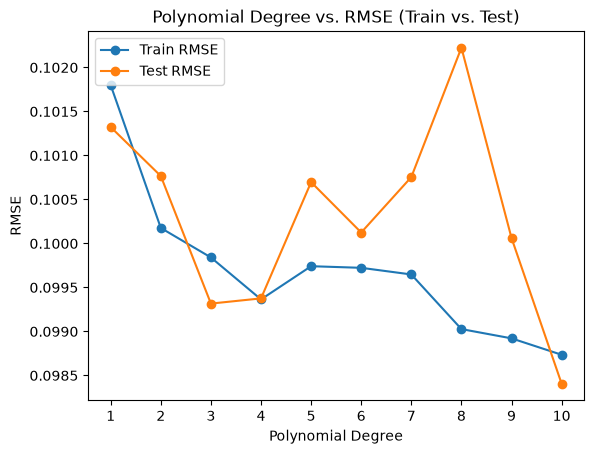

In [10]:
true_function = lambda x: 0.5*x**3 - x**2 + x
epsilon = 0.1

functions = []
degrees = []
train_rmse_values = []
test_rmse_values = []

for i in range(1, 11):
    functions.append(lambda x, i=i: x**i)

    df = generate_noisy_data(
        functions=functions,
        true_function=true_function,
        x_range=[0, 1],
        n_samples=1000,
        epsilon=epsilon
    )

    df_train = df.sample(frac=0.8, random_state=42)
    df_test = df.drop(df_train.index)

    weights = fit(df_train)

    # Test RMSE
    test_X = df_test.drop(columns=["y"])
    test_X.insert(0, "intercept", 1)
    y_preds_test = predict(weights, test_X.T)
    test_rmse = evaluate(y_preds_test, df_test["y"])

    # Train RMSE
    train_X = df_train.drop(columns=["y"])
    train_X.insert(0, "intercept", 1)
    y_preds_train = predict(weights, train_X.T)
    train_rmse = evaluate(y_preds_train, df_train["y"])

    degrees.append(i)
    test_rmse_values.append(test_rmse)
    train_rmse_values.append(train_rmse)

plt.plot(degrees, train_rmse_values, marker="o", label="Train RMSE")
plt.plot(degrees, test_rmse_values, marker="o", label="Test RMSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Polynomial Degree vs. RMSE (Train vs. Test)")
plt.xticks(degrees)
plt.legend()
plt.show()


Problem 8

In [11]:
class TreeNode:
    def __init__(self, data):
        self.data = data
        self.left = None
        self.right = None
        self.feature = None       # feature column used to split
        self.threshold = None     # threshold value used to split
        self.value = data["y"].mean()  # mean y — prediction if this node is reached
        self.is_leaf = False


class RegressionTree:
    def __init__(self):
        # Initialize tree (and additional smaller node classes)
        self.root = None
        self.train_data = None
        self.x_range = None

    def _best_split(self, data):
        # Try every feature and every midpoint threshold, find the one minimizing weighted MSE
        best_loss = float("inf")
        best_feature = None
        best_threshold = None

        features = [col for col in data.columns if col != "y"]

        for feature in features:
            sorted_vals = data[feature].sort_values().unique()
            # Candidate thresholds are midpoints between consecutive unique values
            thresholds = (sorted_vals[:-1] + sorted_vals[1:]) / 2

            for threshold in thresholds:
                left = data[data[feature] <= threshold]
                right = data[data[feature] > threshold]

                if len(left) == 0 or len(right) == 0:
                    continue

                # Weighted sum of variances across both children
                loss = (len(left) * left["y"].var(ddof=0) + len(right) * right["y"].var(ddof=0)) / len(data)

                if loss < best_loss:
                    best_loss = loss
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def fit(self, dataset, min_records):
        # Initialize tree, add entire dataset to the queue
        self.root = TreeNode(dataset)
        self.train_data = dataset

        # Derive x_range from the first feature column in the dataset
        first_feature = [col for col in dataset.columns if col != "y"][0]
        self.x_range = [dataset[first_feature].min(), dataset[first_feature].max()]

        queue = [self.root]

        # While true:
        while queue:
            # Pop first node in the queue
            node = queue.pop(0)

            # Make sure that it has at least min_records
            if len(node.data) < min_records:
                node.is_leaf = True
                continue

            # Split it based on proper splitting criteria (add it's two children)
            feature, threshold = self._best_split(node.data)

            if feature is None:
                node.is_leaf = True
                continue

            node.feature = feature
            node.threshold = threshold

            left_data = node.data[node.data[feature] <= threshold]
            right_data = node.data[node.data[feature] > threshold]

            node.left = TreeNode(left_data)
            node.right = TreeNode(right_data)

            # Add each node to the new tree / Append each to the queue
            queue.append(node.left)
            queue.append(node.right)

    def _predict_row(self, row, node):
        # If leaf, return the mean value stored at this node
        if node.is_leaf or node.feature is None:
            return node.value

        # Traverse left or right based on the split condition
        if row[node.feature] <= node.threshold:
            return self._predict_row(row, node.left)
        else:
            return self._predict_row(row, node.right)

    def predict(self, X):
        # Apply _predict_row to each row in X
        return X.apply(lambda row: self._predict_row(row, self.root), axis=1)

    def visualize(self, true_function=None, ax=None, title=""):
        if ax is None:
            ax = plt.gca()

        features = [col for col in self.train_data.columns if col != "y"]

        # Build a fine grid over x_range for prediction
        x_vals = np.linspace(self.x_range[0], self.x_range[1], 500)
        X_grid = pd.DataFrame({f: x_vals for f in features})
        y_preds = self.predict(X_grid)

        # Scatter training data
        ax.scatter(self.train_data[features[0]], self.train_data["y"], alpha=0.3, s=5, label="Training data")

        # True function curve
        if true_function is not None:
            ax.plot(x_vals, [true_function(x) for x in x_vals], color="green", linewidth=1.5, label="True function")

        # Line plot of tree predictions across x_range
        ax.plot(x_vals, y_preds, color="red", linewidth=2, label="Tree predictions")

        # Draw a vertical line at each split point
        queue = [self.root]
        while queue:
            node = queue.pop(0)
            if not node.is_leaf and node.feature is not None:
                ax.axvline(x=node.threshold, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
                queue.append(node.left)
                queue.append(node.right)

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=7, markerscale=2)


Problem 9

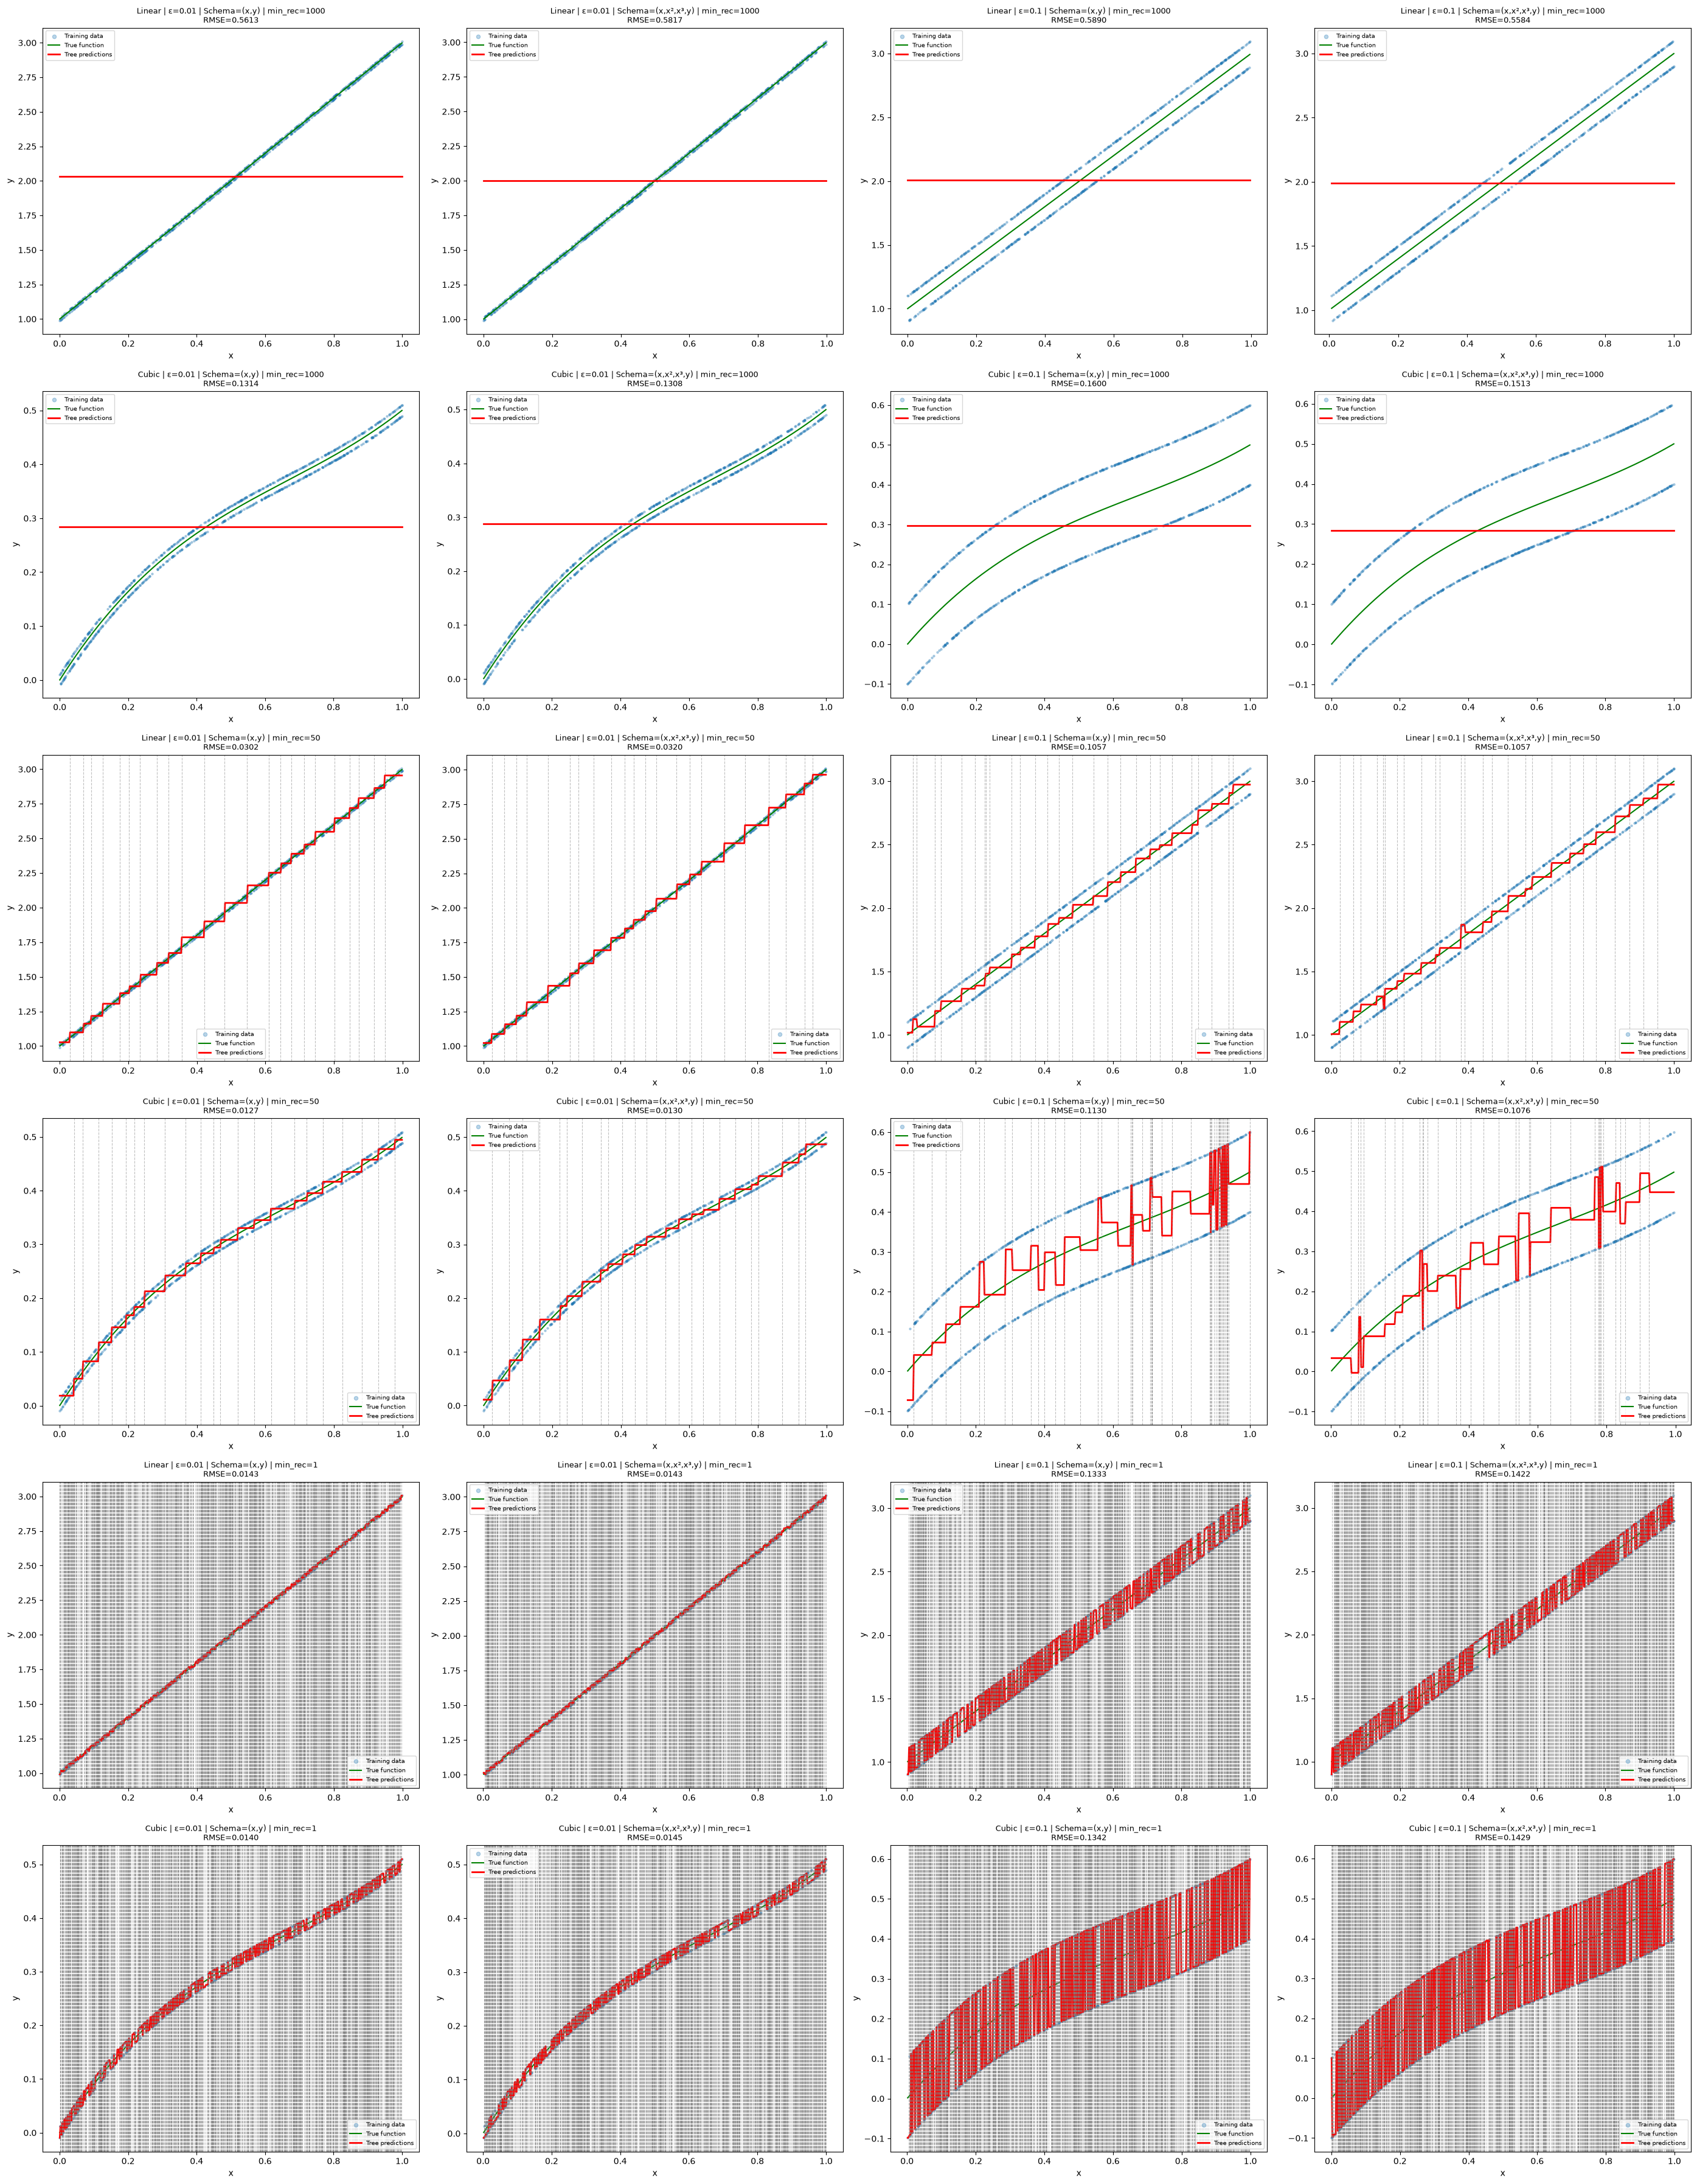

In [12]:
true_functions = {
    "Linear": lambda x: 2*x + 1,
    "Cubic":  lambda x: 0.5*x**3 - x**2 + x
}
epsilons = [0.01, 0.1]
schemas = {
    "(x,y)":         [lambda x: x],
    "(x,x²,x³,y)":  [lambda x: x, lambda x: x**2, lambda x: x**3]
}
min_records_list = [1000, 50, 1]

# 24 total combinations: 2 functions × 2 epsilons × 2 schemas × 3 min_records
n_cols = 4
n_rows = 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 36))
axes = axes.flatten()

idx = 0
for min_rec in min_records_list:
    for fname, true_fn in true_functions.items():
        for eps in epsilons:
            for schema_name, functions in schemas.items():
                df = generate_noisy_data(
                    functions=functions,
                    true_function=true_fn,
                    x_range=[0, 1],
                    n_samples=1000,
                    epsilon=eps
                )

                df_train = df.sample(frac=0.8, random_state=42)
                df_test = df.drop(df_train.index)

                tree = RegressionTree()
                tree.fit(df_train, min_records=min_rec)

                y_preds = tree.predict(df_test.drop(columns=["y"]))
                rmse = evaluate(y_preds, df_test["y"])

                title = f"{fname} | ε={eps} | Schema={schema_name} | min_rec={min_rec}\nRMSE={rmse:.4f}"
                tree.visualize(true_function=true_fn, ax=axes[idx], title=title)
                idx += 1

plt.tight_layout()
plt.show()


Problem 11

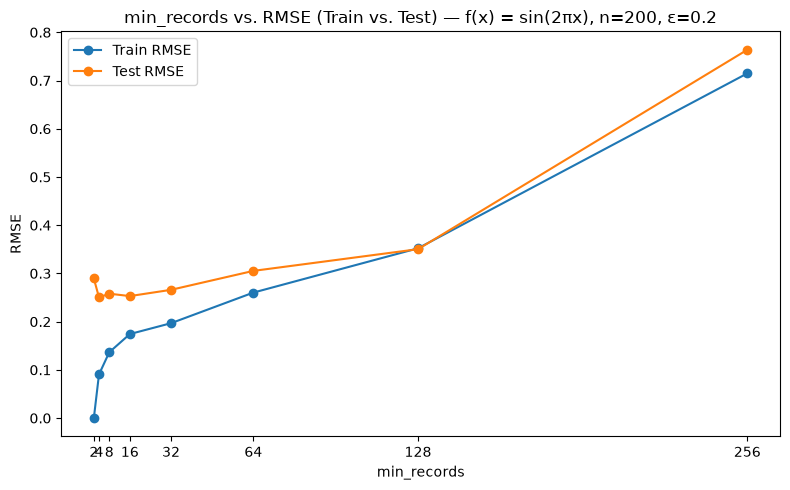

In [13]:
# Generate 200 records using f(x) = sin(2*pi*x) with noise level 0.2
true_function_sin = lambda x: np.sin(2 * np.pi * x)

df_sin = generate_noisy_data(
    functions=[lambda x: x],
    true_function=true_function_sin,
    x_range=[0, 1],
    n_samples=200,
    epsilon=0.2
)

df_sin_train = df_sin.sample(frac=0.8, random_state=42)
df_sin_test = df_sin.drop(df_sin_train.index)

min_records_list = [2, 4, 8, 16, 32, 64, 128, 256]
train_rmse_values = []
test_rmse_values = []

for min_rec in min_records_list:
    tree = RegressionTree()
    tree.fit(df_sin_train, min_records=min_rec)

    # Train RMSE
    y_preds_train = tree.predict(df_sin_train.drop(columns=["y"]))
    train_rmse = evaluate(y_preds_train, df_sin_train["y"])
    train_rmse_values.append(train_rmse)

    # Test RMSE
    y_preds_test = tree.predict(df_sin_test.drop(columns=["y"]))
    test_rmse = evaluate(y_preds_test, df_sin_test["y"])
    test_rmse_values.append(test_rmse)

plt.figure(figsize=(8, 5))
plt.plot(min_records_list, train_rmse_values, marker="o", label="Train RMSE")
plt.plot(min_records_list, test_rmse_values, marker="o", label="Test RMSE")
plt.xlabel("min_records")
plt.ylabel("RMSE")
plt.title("min_records vs. RMSE (Train vs. Test) — f(x) = sin(2πx), n=200, ε=0.2")
plt.xticks(min_records_list)
plt.legend()
plt.tight_layout()
plt.show()
